# Temat
Wpływ warunków pogodowych i sezonowości na zużycie gazu ziemnego w Północnej Karolinie

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('gaz_ziemny_karolinka.csv', sep=';')
df.head()

,Date,_Total NC Natural Gas,_Residential Natural Gas,_Commercial Natural Gas,_Industrial Natural Gas,_Electric Natural Gas,Cooling Degree Days,Cooling_Degree_Days_POW2,Heating Degree Days,Heating_Degree_Days_POW2,...,Month_EQ__03,Month_EQ__04,Month_EQ__05,Month_EQ__06,Month_EQ__07,Month_EQ__08,Month_EQ__09,Month_EQ__10,Month_EQ__11,Month_EQ__12
0,Jan-09,33360,14881.0,8960.0,7722.0,1798.0,0.0,0.0,443.0,196160.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Feb-09,26215,10616.0,6565.0,7121.0,1912.0,0.0,0.0,317.0,100616.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Mar-09,24096,8259.0,5670.0,7493.0,2674.0,6.0,37.0,253.0,64043.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Apr-09,14130,3243.0,3161.0,6412.0,1314.0,23.0,537.0,96.0,9184.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,May-09,11754,1315.0,2464.0,6215.0,1761.0,102.0,10486.0,23.0,514.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.shape
df.isna().sum()

,0
Date,12
_Total NC Natural Gas,12
_Residential Natural Gas,12
_Commercial Natural Gas,12
_Industrial Natural Gas,12
_Electric Natural Gas,12
Cooling Degree Days,12
Cooling_Degree_Days_POW2,12
Heating Degree Days,12
Heating_Degree_Days_POW2,12


# Uzupełnienie danych

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
  df[col].fillna(df[col].mean(), inplace=True)
df.describe()
df.isna().sum()

<ipython-input-157-a913504a0f62>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


,0
Date,12
_Total NC Natural Gas,12
_Residential Natural Gas,0
_Commercial Natural Gas,0
_Industrial Natural Gas,0
_Electric Natural Gas,0
Cooling Degree Days,0
Cooling_Degree_Days_POW2,0
Heating Degree Days,0
Heating_Degree_Days_POW2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      78 non-null     object 
 1   _Total NC Natural Gas     78 non-null     object 
 2   _Residential Natural Gas  90 non-null     float64
 3   _Commercial Natural Gas   90 non-null     float64
 4   _Industrial Natural Gas   90 non-null     float64
 5   _Electric Natural Gas     90 non-null     float64
 6   Cooling Degree Days       90 non-null     float64
 7   Cooling_Degree_Days_POW2  90 non-null     float64
 8   Heating Degree Days       90 non-null     float64
 9   Heating_Degree_Days_POW2  90 non-null     float64
 10  Mean Maximum Temp         90 non-null     float64
 11  Mean MinimumTemp          90 non-null     float64
 12  Mean Temp                 90 non-null     float64
 13  Trend                     90 non-null     float64
 14  Month       

# Cel analizy
Celem analizy jest zbudowanie modelu regresyjnego, który pozwoli oszacować miesięczne zużycie gazu ziemnego na podstawie zmiennych meteorologicznych tj. temperatura, dni grzewcze/chłodzące oraz zmiennej sezonowej: miesiąc. Analiza ma pomóc w zrozumieniu, które czynniki pogodowe mają największy wpływ na zapotrzebowanie na gaz.

# Pytanie badawcze
Czy i jak zmienne pogodowe i sezonowe tłumaczą zmiany w miesięcznym zużyciu gazu ziemnego?



# Zmienna zależna
1) _Residential Natural Gas - Zużycie gazu w sektorze mieszkaniowym


# Zmienne niezależne
- Mean Temp - Średnia temperatura miesiąca
- Heating Degree Days - Wskaźnik zapotrzebowania na ogrzewanie. Wyższe wartości oznaczają chłodniejsze miesiące.
- Cooling Degree Days - Wskaźnik zapotrzebowania na chłodzenie (klimatyzację). Wyższe wartości oznaczają gorętsze miesiące.

🔥 Heating Degree Days (HDD) – dni grzewcze
Służą do oszacowania, jak bardzo i jak długo trzeba było ogrzewać budynek.

Jak to się oblicza:
Ustal temperaturę bazową – zwykle 18°C (lub 65°F w USA).

Dla każdego dnia:

HDD = max(0, temperatura bazowa – średnia dobowa temperatura zewnętrzna)

Sumuj dla całego okresu (np. miesiąca).

Przykład:
Średnia temperatura dnia: 10°C

HDD = 18 – 10 = 8

Jeśli temperatura jest wyższa niż bazowa, HDD = 0 (bo nie trzeba grzać).

❄️ Cooling Degree Days (CDD) – dni chłodzenia
Służą do oszacowania, jak bardzo i jak długo trzeba było chłodzić (klimatyzować) budynek.

Jak to się oblicza:
Temperatura bazowa: znów najczęściej 18°C (65°F).

Dla każdego dnia:

CDD = max(0, średnia temperatura dobowa – temperatura bazowa)

Sumuj dla całego okresu.

Przykład:
Średnia temperatura dnia: 25°C

CDD = 25 – 18 = 7

# Przygotowanie danych do analizy
Zbiór był kompletny i nie wymagał uzupełniania, ani dodawania nowych zmiennych

In [ ]:
df_sorted = df.loc[:77, :'Mean Temp']

In [ ]:
df_numeric = df_sorted.select_dtypes(include=['float'])
df_numeric.head()

,_Residential Natural Gas,_Commercial Natural Gas,_Industrial Natural Gas,_Electric Natural Gas,Cooling Degree Days,Cooling_Degree_Days_POW2,Heating Degree Days,Heating_Degree_Days_POW2,Mean Maximum Temp,Mean MinimumTemp,Mean Temp
0,14881.0,8960.0,7722.0,1798.0,0.0,0.0,443.0,196160.0,9.0,-1.0,4.0
1,10616.0,6565.0,7121.0,1912.0,0.0,0.0,317.0,100616.0,13.0,1.0,7.0
2,8259.0,5670.0,7493.0,2674.0,6.0,37.0,253.0,64043.0,16.0,5.0,10.0
3,3243.0,3161.0,6412.0,1314.0,23.0,537.0,96.0,9184.0,23.0,9.0,16.0
4,1315.0,2464.0,6215.0,1761.0,102.0,10486.0,23.0,514.0,26.0,15.0,21.0


In [ ]:
df_sorted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      78 non-null     object 
 1   _Total NC Natural Gas     78 non-null     object 
 2   _Residential Natural Gas  78 non-null     float64
 3   _Commercial Natural Gas   78 non-null     float64
 4   _Industrial Natural Gas   78 non-null     float64
 5   _Electric Natural Gas     78 non-null     float64
 6   Cooling Degree Days       78 non-null     float64
 7   Cooling_Degree_Days_POW2  78 non-null     float64
 8   Heating Degree Days       78 non-null     float64
 9   Heating_Degree_Days_POW2  78 non-null     float64
 10  Mean Maximum Temp         78 non-null     float64
 11  Mean MinimumTemp          78 non-null     float64
 12  Mean Temp                 78 non-null     float64
dtypes: float64(11), object(2)
memory usage: 8.1+ KB


# Macierz korelacji

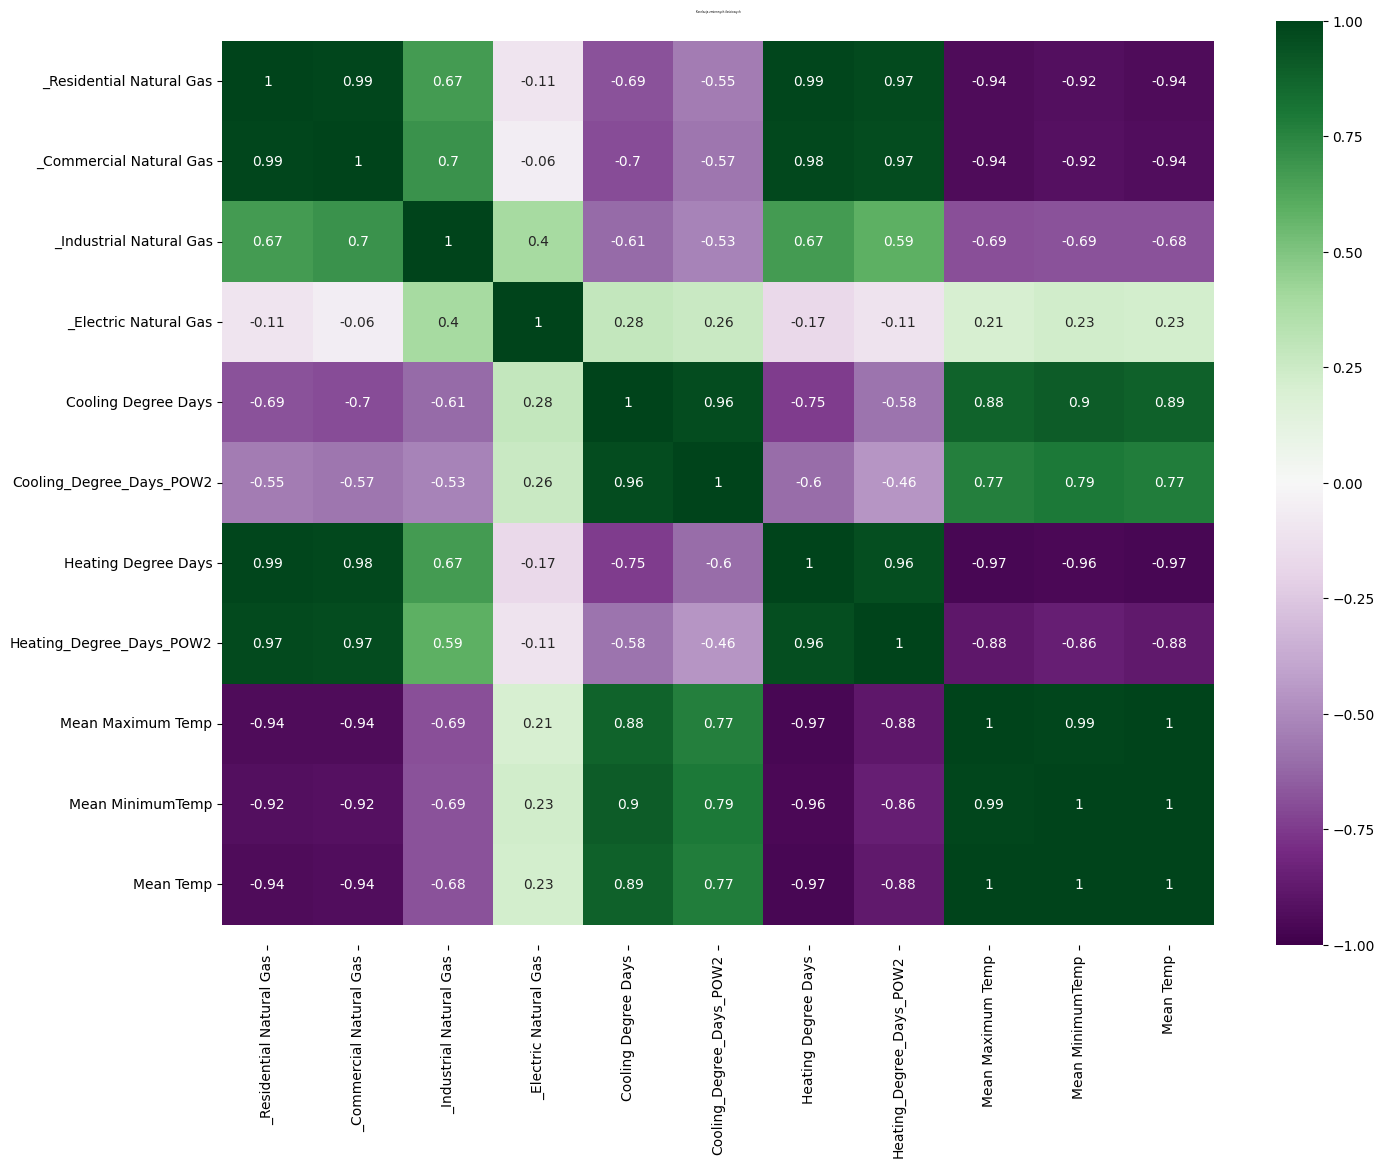

In [ ]:
plt.figure(figsize=(16, 12))

ax = sns.heatmap(df_numeric.corr(),
                 xticklabels=df_numeric.corr().columns,
                 yticklabels=df_numeric.corr().columns,
                 cmap='PRGn',
                 vmin=-1,
                 vmax=1,
                 annot=True,
                 center=0)

plt.title('Korelacja zmiennych ilościowych', fontsize=2)
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.25, top - 0.25)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()

# Analiza macierzy korelacji
Patrząc na pola macierzy ze zmiennymi niezależnymi i ich korelację ze zmienną zależną, można zauważyć, że zmienna Heating Degree Days ma największą dodatnią korelację ze zmienną zależną _Residental Natural Gas, ma to sens ponieważ rosnące zapotrzebowanie na ogrzewanie powoduje, że rośnie zużycie  gazu. Podobnie przy Cooling Degree Days, można zauważyć odwrotną korelacje do zużycia gazu, gdyż im mniejsze zapotrzebowanie tym mniejsze zużycie gazu, nie jest to tak silna korelacja co prawda jak w przypadku Heating Degree Days. Wprzypadku Mean Temp, również można zauważyć silną ujemną korelację, ponieważ im wyższa średnia temperatura w danym miesiący tym niższe zużycie gazu.

# Wykresy

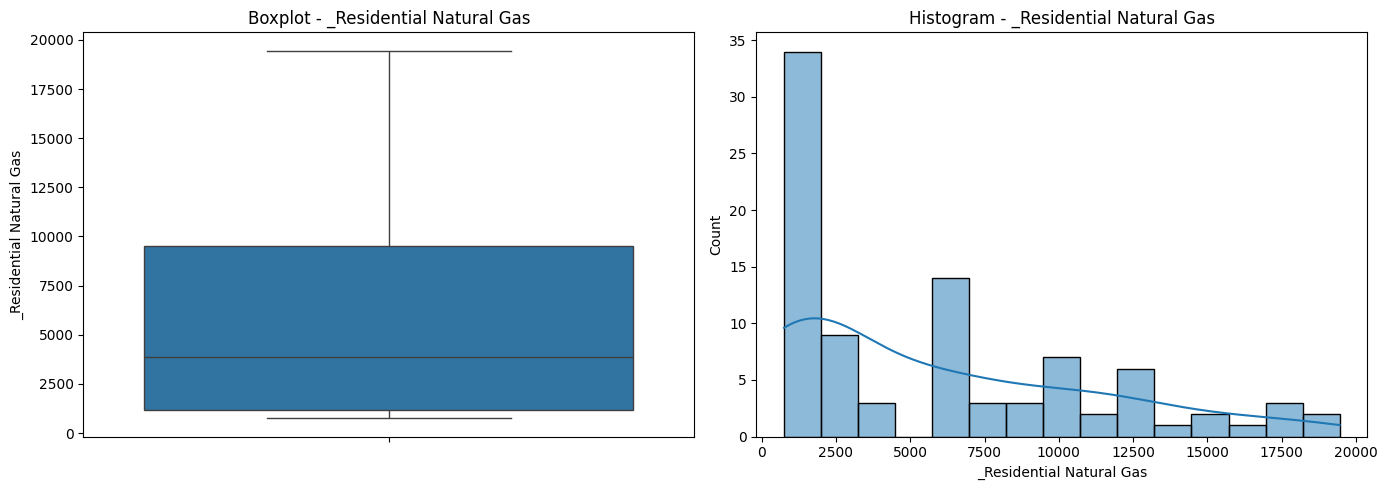

In [ ]:
target_variable = '_Residential Natural Gas'

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, y=target_variable, ax=axs[0])
axs[0].set_title('Boxplot - _Residential Natural Gas')

sns.histplot(data=df, x=target_variable, kde=True, bins=15, ax=axs[1])
axs[1].set_title('Histogram - _Residential Natural Gas')

plt.tight_layout()
plt.show()



# Opis wykresów
Na wykresie po lewej stronie znajduje się boxplot prezentujący ogólny rozkład zużycia gazu ziemnego w sektorze mieszkaniowym (_Residential Natural Gas), bez podziału na miesiące ciepłe i zimne. Mediana zużycia wynosi około 3 800 jednostek, a rozpiętość danych jest duża – od wartości poniżej 1 000 aż do prawie 20 000. Widać silną asymetrię – większość wartości mieści się w dolnej połowie rozkładu, natomiast górny kwartyl obejmuje szeroki zakres, wskazując na występowanie wielu miesięcy o bardzo wysokim zużyciu (najpewniej zimowych).

Wykres po prawej stronie to histogram z krzywą gęstości rozkładu, który pokazuje liczbę miesięcy dla różnych poziomów zużycia gazu. Dominują miesiące o bardzo niskim zużyciu (500–2 000 jednostek), co wskazuje, że większość roku charakteryzuje się małym zapotrzebowaniem na gaz. Jednak histogram ma długi prawostronny ogon, co oznacza, że w mniejszej liczbie miesięcy występują wartości znacznie wyższe – od 6 000 do nawet 20 000 jednostek. Te miesiące prawdopodobnie przypadają na okres grzewczy. Całość wskazuje na silnie niesymetryczny, prawostronnie skośny rozkład, z dominacją niskich wartości i nielicznymi przypadkami bardzo wysokiego zużycia.











In [ ]:
df['Warm_Month'] = np.where(df['Mean Temp'] >= 12, 'warm', 'cold')
df.head()

,Date,_Total NC Natural Gas,_Residential Natural Gas,_Commercial Natural Gas,_Industrial Natural Gas,_Electric Natural Gas,Cooling Degree Days,Cooling_Degree_Days_POW2,Heating Degree Days,Heating_Degree_Days_POW2,...,Month_EQ__04,Month_EQ__05,Month_EQ__06,Month_EQ__07,Month_EQ__08,Month_EQ__09,Month_EQ__10,Month_EQ__11,Month_EQ__12,Warm_Month
0,Jan-09,33360,14881.0,8960.0,7722.0,1798.0,0.0,0.0,443.0,196160.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cold
1,Feb-09,26215,10616.0,6565.0,7121.0,1912.0,0.0,0.0,317.0,100616.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cold
2,Mar-09,24096,8259.0,5670.0,7493.0,2674.0,6.0,37.0,253.0,64043.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cold
3,Apr-09,14130,3243.0,3161.0,6412.0,1314.0,23.0,537.0,96.0,9184.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,warm
4,May-09,11754,1315.0,2464.0,6215.0,1761.0,102.0,10486.0,23.0,514.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,warm


# Wykresy sketegoryzowane

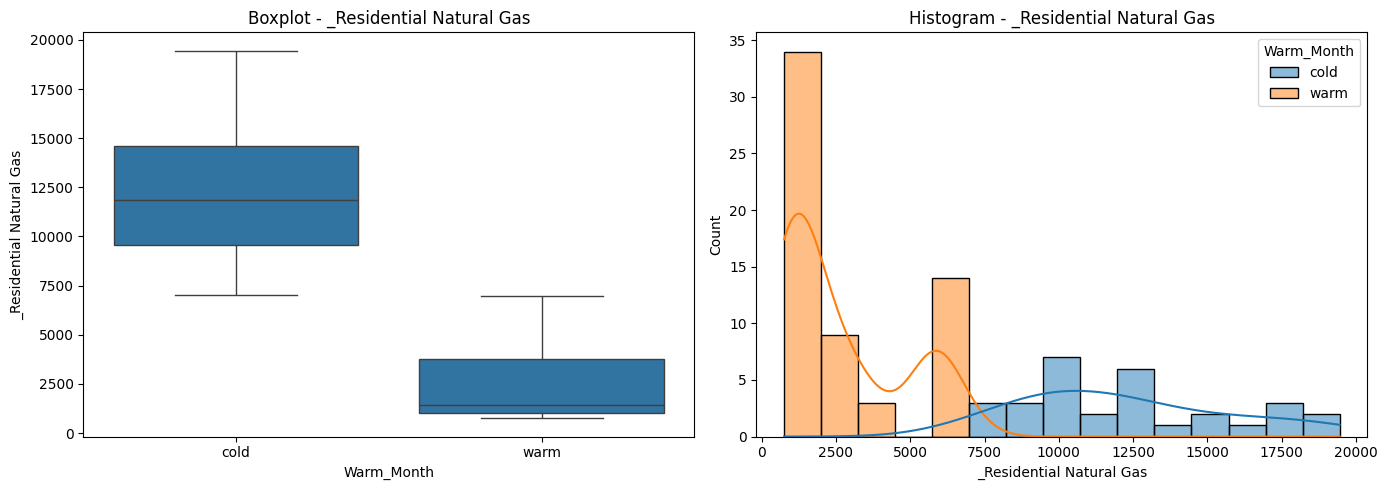

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df,x='Warm_Month', y=target_variable, ax=axs[0])
axs[0].set_title('Boxplot - _Residential Natural Gas')

sns.histplot(data=df, x=target_variable, hue='Warm_Month', kde=True, bins=15, ax=axs[1])
axs[1].set_title('Histogram - _Residential Natural Gas')

plt.tight_layout()
plt.show()


# Analiza Wykresu
Na wykresie po lewej stronie przedstawiono boxplot ilustrujący zużycie gazu ziemnego w sektorze mieszkaniowym w podziale na miesiące zimne i ciepłe. W miesiącach zimnych (cold) zużycie jest wyraźnie wyższe – mediana wynosi ok. 12 000 jednostek, a wartości mieszczą się w szerokim zakresie od około 7 000 do 20 000. W miesiącach ciepłych (warm) zużycie spada drastycznie – większość obserwacji oscyluje wokół 1 500 jednostek, a cały rozkład jest znacznie bardziej skupiony i niższy. Taki rozkład wskazuje, że gaz zimą wykorzystywany jest głównie do ogrzewania mieszkań.

Histogram po prawej stronie uzupełnia tę analizę, pokazując liczność miesięcy o określonym zużyciu gazu, oddzielnie dla zimnych i ciepłych miesięcy. Miesiące ciepłe mają wyraźnie skupione zużycie w najniższych przedziałach (do 3 000 jednostek), co potwierdza niskie zapotrzebowanie na gaz, prawdopodobnie ograniczone do gotowania i podgrzewania wody. W miesiącach zimnych natomiast rozkład jest znacznie bardziej rozproszony i przesunięty w stronę wyższych wartości – zużycie często przekracza 10 000 jednostek. Obie wizualizacje jednoznacznie pokazują sezonowość zużycia gazu w gospodarstwach domowych, silnie uzależnioną od temperatury i potrzeby ogrzewania.

# Weryfikacja hipotezy o zgodności rozkładu zmiennej zależnej z rozkładem normalnym

In [ ]:
from scipy.stats import shapiro

y = df['_Residential Natural Gas']
stat, p_value = shapiro(y)
print(f'Statystyka testu: {stat:.4f}, p-value: {p_value:.4f}')

if p_value > 0.05:
    print("Brak podstaw do odrzucenia H0: rozkład jest zgodny z normalnym")
else:
    print("Odrzucamy H0: rozkład nie jest zgodny z normalnym")


Statystyka testu: 0.8547, p-value: 0.0000
Odrzucamy H0: rozkład nie jest zgodny z normalnym


Statystyka testu: 0.8547, p-value: 0.0000

Odrzucamy H0: rozkład nie jest zgodny z normalnym

Wniosek: Rozkład zużycia gazu jest wyraźnie nienormalny.

# Czy zmienna zależna (_Residental Natural Gas) ma rozkład normalny?
Zmienna _Residental Natural Gas nie ma rozkładu normalnego. Wynika to z wykresów powyżej.
Na wykresie zmiennej brakuje symetrii, przy rozkładzie normalnym prawa i lewa strona powinny być lustrzanymi odbiciami czego wyraźnie brakuje w przypadku tej zmiennej. Wykres nie ma pojedynczego szczytu co jest wymagane przy rozkładzie normalnym.

In [ ]:
df['Cooling month'] = np.where(df['Cooling Degree Days'] > 0, 1, 0)
df.head()

,Date,_Total NC Natural Gas,_Residential Natural Gas,_Commercial Natural Gas,_Industrial Natural Gas,_Electric Natural Gas,Cooling Degree Days,Cooling_Degree_Days_POW2,Heating Degree Days,Heating_Degree_Days_POW2,...,Month_EQ__05,Month_EQ__06,Month_EQ__07,Month_EQ__08,Month_EQ__09,Month_EQ__10,Month_EQ__11,Month_EQ__12,Warm_Month,Cooling month
0,Jan-09,33360,14881.0,8960.0,7722.0,1798.0,0.0,0.0,443.0,196160.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cold,0
1,Feb-09,26215,10616.0,6565.0,7121.0,1912.0,0.0,0.0,317.0,100616.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cold,0
2,Mar-09,24096,8259.0,5670.0,7493.0,2674.0,6.0,37.0,253.0,64043.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cold,1
3,Apr-09,14130,3243.0,3161.0,6412.0,1314.0,23.0,537.0,96.0,9184.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,warm,1
4,May-09,11754,1315.0,2464.0,6215.0,1761.0,102.0,10486.0,23.0,514.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,warm,1


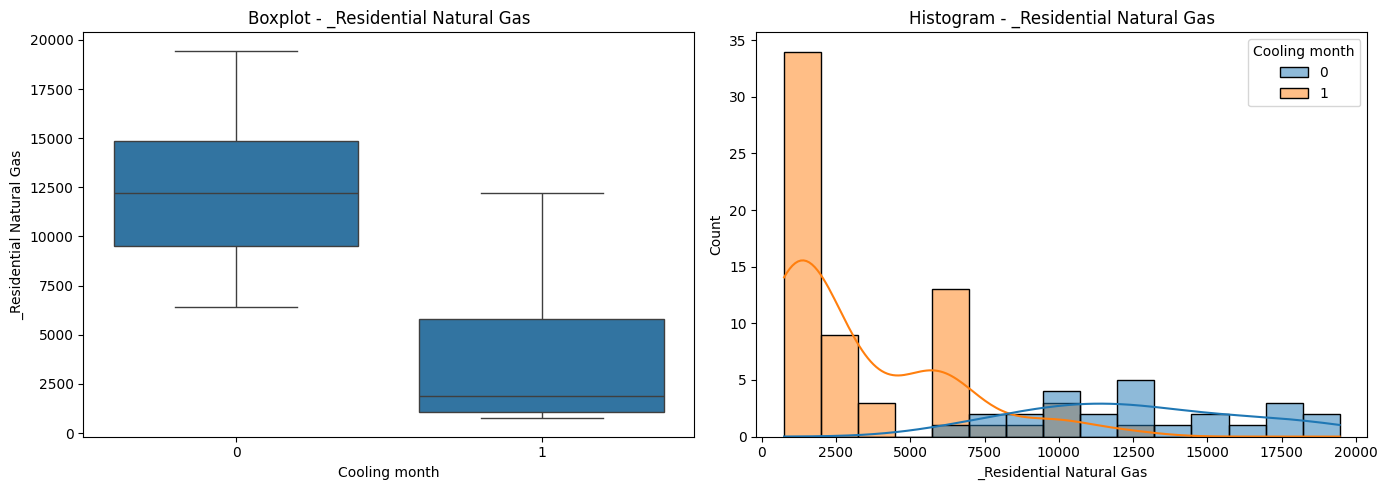

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df,x='Cooling month', y=target_variable, ax=axs[0])
axs[0].set_title('Boxplot - _Residential Natural Gas')

sns.histplot(data=df, x=target_variable, hue='Cooling month', kde=True, bins=15, ax=axs[1])
axs[1].set_title('Histogram - _Residential Natural Gas')

plt.tight_layout()
plt.show()


# Model regresji jednej zmiennej

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [ ]:
x = df[['Mean Temp']]
y = df['_Residential Natural Gas']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
print('y = ', model.coef_, 'x + ', model.intercept_)

y =  [-647.56312472] x +  16042.455735961796


In [ ]:
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

print("Predykcja na zbiorze treningowym:")
print(y_pred_train)

print("\nPredykcja na zbiorze testowym:")
y_pred_test

Predykcja na zbiorze treningowym:
[12804.64011235 10861.95073819 14747.32948652  5033.88261569
  1796.06699208 -2089.31175625  6329.00886513 13452.20323707
  -146.62238208   500.94074264  -794.18550681  5681.44574041
  6329.00886513  1796.06699208  -146.62238208 -2089.31175625
 10214.38761347  1796.06699208  5681.44574041  8271.6982393
  -794.18550681  5888.99802398  5033.88261569 -1441.74863153
  5888.99802398 10861.95073819   500.94074264 14099.7663618
 14099.7663618   5681.44574041 -1441.74863153  5681.44574041
  1796.06699208  5888.99802398  -146.62238208  2443.6301168
 11509.51386291  5888.99802398  5888.99802398  -794.18550681
  -146.62238208 11509.51386291 10214.38761347 12157.07698763
  5888.99802398  5033.88261569 13452.20323707   500.94074264
 10214.38761347 11509.51386291  5888.99802398  5033.88261569
  1796.06699208  5888.99802398 10861.95073819  5681.44574041
  -794.18550681 10861.95073819  -794.18550681 11509.51386291
  3738.75636625  5033.88261569  9566.82448874 15394.89

array([ 1796.06699208,  9566.82448874,   500.94074264, 10861.95073819,
       13452.20323707,  8919.26136402,  5681.44574041,  -146.62238208,
        8271.6982393 ,  1796.06699208,  5888.99802398, 10214.38761347,
        1796.06699208,  5888.99802398, 14099.7663618 ,  2443.6301168 ,
       -2089.31175625,  2443.6301168 ])

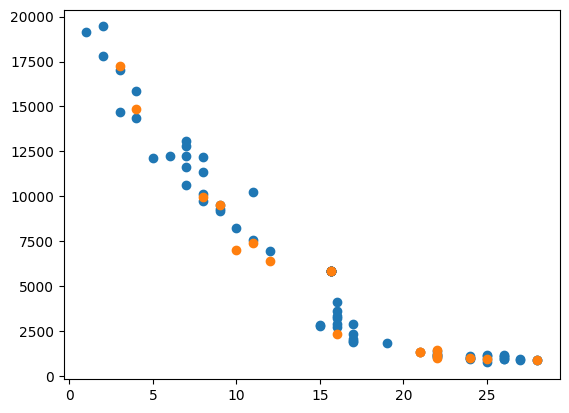

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x_train, y_train, label='Dane treningowe')
ax.scatter(x_test, y_test, label='Dane testowe')

In [ ]:
R2_train = r2_score(y_train, model.predict(x_train))
R2_test = r2_score(y_test, model.predict(x_test))
MAE_train = mean_absolute_error(y_train, model.predict(x_train))
MAE_test = mean_absolute_error(y_test, model.predict(x_test))
MSE_train = mean_squared_error(y_train, model.predict(x_train))
MSE_test = mean_squared_error(y_test, model.predict(x_test))
RMSE_train = root_mean_squared_error(y_train, model.predict(x_train))
RMSE_test = root_mean_squared_error(y_test, model.predict(x_test))
print("R2_train:", R2_train)
print("R2_test:", R2_test)
print("MAE_train:", MAE_train)
print("MAE_test:", MAE_test)
print("MSE_train:", MSE_train)
print("MSE_test:", MSE_test)
print("RMSE_train:", RMSE_train)
print("RMSE_test:", RMSE_test)

R2_train: 0.8799296033876735
R2_test: 0.8824376002403377
MAE_train: 1443.7496890470725
MAE_test: 1342.8602853441419
MSE_train: 3332586.6404173863
MSE_test: 2809339.901066845
RMSE_train: 1825.537356620616
RMSE_test: 1676.1085588549581


# Analiza modelu jednej zmiennej

Trening: 0.880, Test: 0.882

Około 88% zmienności zużycia gazu da się wyjaśnić za pomocą samej średniej temperatury. Choć to dużo, wynik może być wyraznie w modelu wielozmiennowym, uwzględnienie dodatkowych zmiennych, takich jak dni z zapotrzebowaniem na chłodzenie i dni z zapotrzebowaniem na klimatyzację, może poprawić dopasowanie.

Wykres rozrzutu wypłaszcza się przy końcu, co oznacza, że w zakresie wyższych temperatur (cieplejsze miesiące) związek między temperaturą a zużyciem gazu przestaje być liniowy.

Mean Temp sama w sobie nie wystarcza, by precyzyjnie przewidzieć zużycie gazu, mimo wysokiej korelacji.



# Model regresji liniowej wielu zmiennych

In [ ]:
x = df[['Mean Temp', 'Cooling Degree Days', 'Heating Degree Days']]
y = df['_Residential Natural Gas']
x_train1, x_test1, y_train1, y_test1 = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
model1 = LinearRegression()
model1.fit(x_train1, y_train1)

LinearRegression()

In [ ]:
print('y = ', model1.coef_[0], 'x + ', model1.coef_[1], 'x + ', model1.coef_[2], 'x + ', model1.intercept_)

y =  -49.58010887214945 x +  8.14788310386811 x +  34.95004756240026 x +  437.52161261594847


In [ ]:
y_pred_train1 = model1.predict(x_train1)
y_pred_test1 = model1.predict(x_test1)

print("Predykcja na zbiorze treningowym:")
print(y_pred_train1)

print("\nPredykcja na zbiorze testowym:")
y_pred_test1

Predykcja na zbiorze treningowym:
[12806.58823828 11469.54629454 16380.43322601  2433.54765763
   676.36418066  1469.19984604  3926.20658739 15372.57177165
   982.40529056   754.9573739   1169.1137917   2783.7409435
  3609.29764419   604.10557039   835.74339469  1493.64349536
 10021.96428318   881.34743574  3476.95252679  7013.1094244
  1144.67014239  5863.49650774  2533.68077002  1290.63922801
  5863.49650774  9800.09189465   697.92219217 15212.45159514
 17204.6043062   3186.84574804  1217.30828007  3509.54405921
   403.83934561  5863.49650774   990.55317366   832.08060971
 12462.7776876   5863.49650774  5863.49650774  1022.45189583
   925.37010883 12113.27721198 10266.61461611 11743.4567501
  5863.49650774  2153.94727713 15547.32200946   578.06246076
 10231.66456855 12707.42802054  5863.49650774  2766.75236704
   763.63237966  5863.49650774 11754.936043    3016.81254052
  1138.88077443 10490.9449628   1046.89554514 11169.62592779
  1753.96004256  2209.91012119  8832.9698558  18841.56

array([  595.95768729,  8189.93174862,   789.90742146, 10778.6932264 ,
       15722.07224727,  8355.84129308,  3423.34819787,   843.89127779,
        6902.46991376,   446.93727627,  5863.49650774, 10371.4647588 ,
         428.28299492,  5863.49650774, 17029.85406839,  1031.27449683,
        1404.01678121,  1049.92877819])

In [ ]:
R2_train1 = r2_score(y_train1, model1.predict(x_train1))
R2_test1 = r2_score(y_test1, model1.predict(x_test1))
MAE_train1 = mean_absolute_error(y_train1, model1.predict(x_train1))
MAE_test1 = mean_absolute_error(y_test1, model1.predict(x_test1))
MSE_train1 = mean_squared_error(y_train1, model1.predict(x_train1))
MSE_test1 = mean_squared_error(y_test1, model1.predict(x_test1))
RMSE_train1 = root_mean_squared_error(y_train1, model1.predict(x_train1))
RMSE_test1 = root_mean_squared_error(y_test1, model1.predict(x_test1))
print("R2_train:", R2_train1)
print("R2_test:", R2_test1)
print("MAE_train:", MAE_train1)
print("MAE_test:", MAE_test1)
print("MSE_train:", MSE_train1)
print("MSE_test:", MSE_test1)
print("RMSE_train:", RMSE_train1)
print("RMSE_test:", RMSE_test1)

R2_train: 0.9878980975303409
R2_test: 0.9814730218517106
MAE_train: 412.7341710895805
MAE_test: 561.1240599326686
MSE_train: 335891.6071897085
MSE_test: 442731.51164477895
RMSE_train: 579.5615646242499
RMSE_test: 665.3807268359815


# Analiza modelu wielu zmiennych

Trening: 0.9879, Test: 0.9815

Model bardzo dobrze dopasowuje się do danych. Wartości R² bliskie 1 wskazują, że większość zmienności zużycia gazu jest wyjaśniana przez zmienne niezależne. Niewielki spadek R² na zbiorze testowym świadczy o dobrej generalizacji.

Niskie wartości błędów zarówno dla zbioru treningowego, jak i testowego wskazują, że model nie tylko dobrze dopasowuje się do danych uczących, ale też trafnie prognozuje nowe dane.

Różnice między błędami treningowymi i testowymi są umiarkowane, co oznacza, że model nie przeucza się i zachowuje równowagę między dopasowaniem a uogólnieniem.

# Wnioski

Model jednowymiarowy jest zaskakująco skuteczny, ale nie wystarczająco precyzyjny, jeśli zależy nam na dokładnych prognozach.

Model wielu zmiennych jest skuteczny – wysokie R² i niskie błędy na obu zbiorach świadczą o dobrze działającym modelu regresji.

Zmienność zużycia gazu jest silnie powiązana z czynnikami pogodowymi, w szczególności z liczbą dni grzewczych i średnią temperaturą.